# A04 Vertical Slice: Predictive Maintenance
Load the AI4I 2020 dataset, confirm the failure distribution, build a baseline and a first comparison model, and produce one chart.

**Team:** Alex Johnson, Anthony Fuentes, Joey Brekan, Abraham Perez

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt


## 1. Load the data and check the schema

In [4]:
df = pd.read_csv('../data/raw/ai4i2020.csv')
print('Shape:', df.shape)
print()
print('Columns:', list(df.columns))
print()
print(df.isnull().sum().sum(), 'total missing values')

Shape: (10000, 14)

Columns: ['UID', 'Product ID', 'Type', 'Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

0 total missing values


## 2. Confirm the failure distribution

In [6]:
print(df['Machine failure'].value_counts())
print()
print('Failure rate: {:.2%}'.format(df['Machine failure'].mean()))

Machine failure
0    9661
1     339
Name: count, dtype: int64

Failure rate: 3.39%


## 3. Select predictors and split the data
Excluding UDI, Product ID, and the five failure-mode flags (TWF, HDF, PWF, OSF, RNF) since these either identify a specific row or leak the outcome.

In [8]:
predictors = ['Air temperature', 'Process temperature',
                   'Rotational speed', 'Torque', 'Tool wear']
X = df[predictors]
y = df['Machine failure']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('Train size:', X_train.shape[0], '| Test size:', X_test.shape[0])
print('Failures in test set:', y_test.sum(), 'of', len(y_test))

Train size: 8000 | Test size: 2000
Failures in test set: 68 of 2000


## 4. Baseline: always predict 'no failure'

In [10]:
baseline = DummyClassifier(strategy='constant', constant=0)
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

print(classification_report(y_test, baseline_pred, digits=3, zero_division=0))
print('Confusion matrix:')
print(confusion_matrix(y_test, baseline_pred))

              precision    recall  f1-score   support

           0      0.966     1.000     0.983      1932
           1      0.000     0.000     0.000        68

    accuracy                          0.966      2000
   macro avg      0.483     0.500     0.491      2000
weighted avg      0.933     0.966     0.949      2000

Confusion matrix:
[[1932    0]
 [  68    0]]


## 5. First comparison model: logistic regression
Using `class_weight='balanced'` since failures are rare (3.39% of rows).

In [12]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)
model_pred = model.predict(X_test)

print(classification_report(y_test, model_pred, digits=3, zero_division=0))
print('Confusion matrix:')
print(confusion_matrix(y_test, model_pred))

              precision    recall  f1-score   support

           0      0.992     0.821     0.899      1932
           1      0.139     0.824     0.238        68

    accuracy                          0.821      2000
   macro avg      0.566     0.822     0.568      2000
weighted avg      0.963     0.821     0.876      2000

Confusion matrix:
[[1586  346]
 [  12   56]]


**Reading this result:** at the default 0.5 threshold, logistic regression catches 56 of 68 real failures (82.4% recall) but flags 346 of 1,932 healthy machines as false alarms, a 17.9% false-alarm rate. That's above the 10% limit the team set in Section 3.

## 6. One chart: torque by failure status

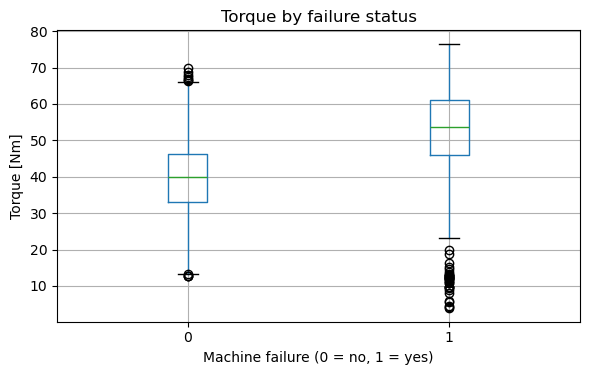

In [15]:
fig, ax = plt.subplots(figsize=(6, 4))
df.boxplot(column='Torque', by='Machine failure', ax=ax)
ax.set_xlabel('Machine failure (0 = no, 1 = yes)')
ax.set_ylabel('Torque [Nm]')
ax.set_title('Torque by failure status')
plt.suptitle('')
plt.tight_layout()
plt.show()

## Status and known limitation

**Test status:** ran end to end without errors, on the full ai4i2020.csv (10,000 rows).

**Known limitation:** the logistic regression above was trained with default settings and a 0.5 threshold, just to prove the pipeline works. It has not been tuned yet, the actual threshold recommendation still needs to test a range of threshold values to find one that keeps false alarms under the team's 10% limit.

**Run by:** Anthony Fuentes